# Đồ án 2: Data Fitting và Phương pháp OLS
## Phần 1: Lý thuyết Data Fitting và Minh họa

Họ và tên: [Tên của bạn]  
MSSV: [MSSV của bạn]  

---

### 1. Ordinary Least Squares (OLS) 

#### 1.1. Công thức toán học
Mô hình hồi quy tuyến tính: $y = X\beta + \varepsilon$

- Nghiệm OLS (Normal Equations): $\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$
- Ma trận chiếu (Hat Matrix): $H = X(X^T X)^{-1} X^T$
- Ước lượng phương sai nhiễu: $\hat{\sigma}^2 = \frac{RSS}{n - (p+1)}$

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference, vif, run_monte_carlo
from ridge_lasso import ridge_fit, lasso_trace
from residual_analysis import residual_plots
from cross_validation import kfold_cv

# 1. Sinh dữ liệu giả lập
np.random.seed(42)
n, p = 100, 3
X_base = np.random.randn(n, p)
X = np.hstack([np.ones((n, 1)), X_base]) # Thêm cột intercept
true_beta = np.array([2.5, 1.5, -2.0, 3.0])
y = X @ true_beta + np.random.normal(0, 1.0, n)

# 2. Cài đặt từ đầu
beta_hat, sigma2_hat = ols_fit(X, y)
print("Hệ số beta ước lượng (Self):", beta_hat.round(4))
print("Ước lượng sigma^2 (Self):", round(sigma2_hat, 4))

# 3. Kiểm chứng với Scikit-learn
model = LinearRegression(fit_intercept=False).fit(X, y)
print("Hệ số beta (Sklearn):     ", model.coef_.round(4))
assert np.allclose(beta_hat, model.coef_), "FAIL: Kết quả không khớp với Sklearn!"

Hệ số beta ước lượng (Self): [ 2.6129  1.4223 -2.05    2.8924]
Ước lượng sigma^2 (Self): 0.7883
Hệ số beta (Sklearn):      [ 2.6129  1.4223 -2.05    2.8924]


### 2. Ma trận chiếu (Hat Matrix)

Tính chất của $H$:
1. Idempotent: $H^2 = H$
2. Đối xứng: $H^T = H$
3. $rank(H) = p + 1$

In [2]:
H = hat_matrix(X)
print("Đã kiểm tra các tính chất của Hat Matrix thông qua assert trong hàm hat_matrix.")
print("Rank của H:", np.linalg.matrix_rank(H))

Đã kiểm tra các tính chất của Hat Matrix thông qua assert trong hàm hat_matrix.
Rank của H: 4


### 3. Đánh giá mô hình và Kiểm định thống kê

- RSS (Residual Sum of Squares): $\sum (y_i - \hat{y}_i)^2$
- $R^2$: Hệ số xác định.
- Adjusted $R^2$: Phạt khi thêm nhiều biến.
- F-test: Kiểm định ý nghĩa toàn bộ mô hình.
- t-test: Kiểm định ý nghĩa từng hệ số $\beta_j$.

In [3]:
y_hat = X @ beta_hat
rss, tss, r2, r2_adj, f_stat, f_pvalue = model_metrics(y, y_hat, p)
print(f"R-squared: {r2:.4f}")
print(f"Adj R-squared: {r2_adj:.4f}")
print(f"F-statistic: {f_stat:.4f} (p-value: {f_pvalue:.4e})")

se, t_stat, p_values, ci = coef_inference(X, y, beta_hat, sigma2_hat)
inference_df = pd.DataFrame({
    'Beta_Hat': beta_hat,
    'Std_Error': se,
    't_stat': t_stat,
    'p_value': p_values,
    'CI_Lower': ci[0],
    'CI_Upper': ci[1]
})
print("\nThống kê suy diễn hệ số:")
display(inference_df)

R-squared: 0.9562
Adj R-squared: 0.9548
F-statistic: 698.4047 (p-value: 1.1102e-16)

Thống kê suy diễn hệ số:


,Beta_Hat,Std_Error,t_stat,p_value,CI_Lower,CI_Upper
0,2.612862,0.090950,28.728611,0.0,2.432328,2.793396
1,1.422337,0.109212,13.023575,0.0,1.205552,1.639122
2,-2.049964,0.092036,-22.273482,0.0,-2.232654,-1.867273
3,2.892407,0.081470,35.502699,0.0,2.730690,3.054123


### 4. Đa cộng tuyến (VIF)

VIF (Variance Inflation Factor) giúp phát hiện sự phụ thuộc tuyến tính giữa các biến độc lập.
$VIF_j = \frac{1}{1 - R_j^2}$

In [4]:
vif_results = vif(X)

=== Kết quả VIF ===
  VIF(X1) = 1.0190
  VIF(X2) = 1.0198
  VIF(X3) = 1.0324


### 5. Ridge và Lasso Regression

- **Ridge**: Thêm phần phạt $L_2$: $\|\beta\|_2^2$
- **Lasso**: Thêm phần phạt $L_1$: $\|\beta\|_1$

Vẽ biểu đồ Ridge Trace:


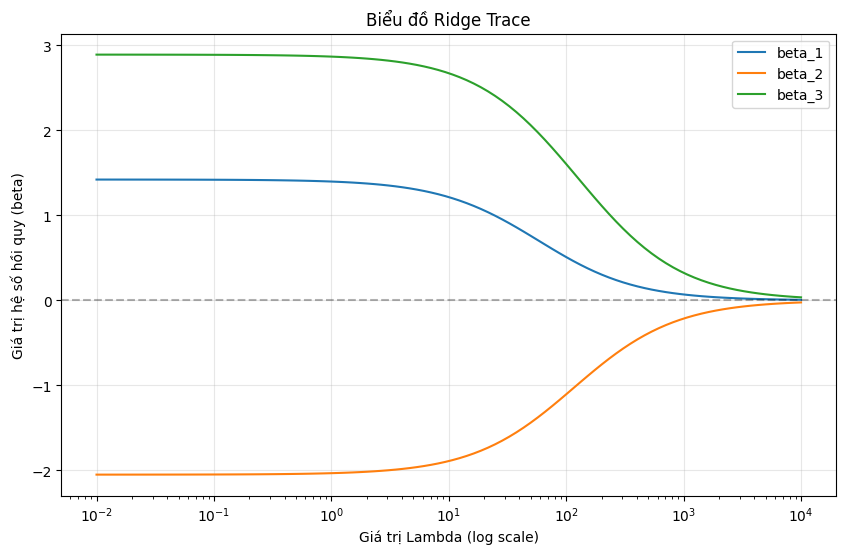

Vẽ biểu đồ Lasso Trace:


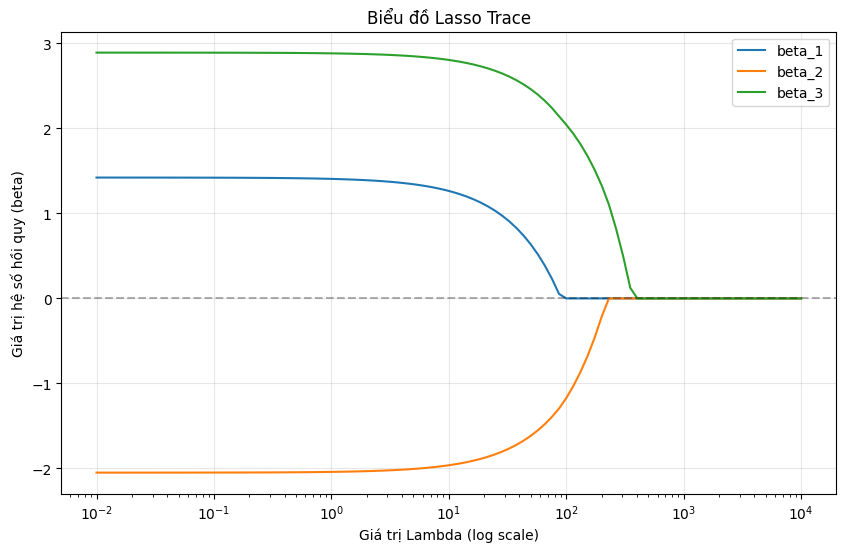

array([[ 2.61289944,  1.42217877, -2.04987692,  2.89232041],
       [ 2.61290495,  1.42215518, -2.04986392,  2.89230751],
       [ 2.61291129,  1.42212806, -2.04984898,  2.89229267],
       [ 2.61291857,  1.42209688, -2.0498318 ,  2.8922756 ],
       [ 2.61292695,  1.42206102, -2.04981204,  2.89225598],
       [ 2.61293658,  1.4220198 , -2.04978933,  2.89223342],
       [ 2.61294766,  1.42197241, -2.04976322,  2.89220749],
       [ 2.61296039,  1.42191792, -2.04973319,  2.89217767],
       [ 2.61297503,  1.42185527, -2.04969867,  2.89214338],
       [ 2.61299186,  1.42178323, -2.04965898,  2.89210396],
       [ 2.61301122,  1.42170041, -2.04961334,  2.89205864],
       [ 2.61303347,  1.42160519, -2.04956087,  2.89200653],
       [ 2.61305905,  1.4214957 , -2.04950054,  2.89194662],
       [ 2.61308847,  1.42136982, -2.04943118,  2.89187773],
       [ 2.61312229,  1.42122509, -2.04935143,  2.89179852],
       [ 2.61316118,  1.42105868, -2.04925973,  2.89170746],
       [ 2.61320588,  1.

In [5]:
lam_list = np.logspace(-2, 4, 100)
print("Vẽ biểu đồ Ridge Trace:")
ridge_fit(X, y, lam_list)

print("Vẽ biểu đồ Lasso Trace:")
lasso_trace(X, y, lam_list)

### 6. Phân tích phần dư (Residual Analysis)

Sử dụng 4 biểu đồ để kiểm tra các giả thiết Gauss-Markov.
1. Residuals vs Fitted: Tuyến tính và đồng phương sai.
2. Normal Q-Q: Tính chuẩn của sai số.
3. Scale-Location: Kiểm tra đồng phương sai.
4. Cook's Distance: Xác định điểm ảnh hưởng lớn.

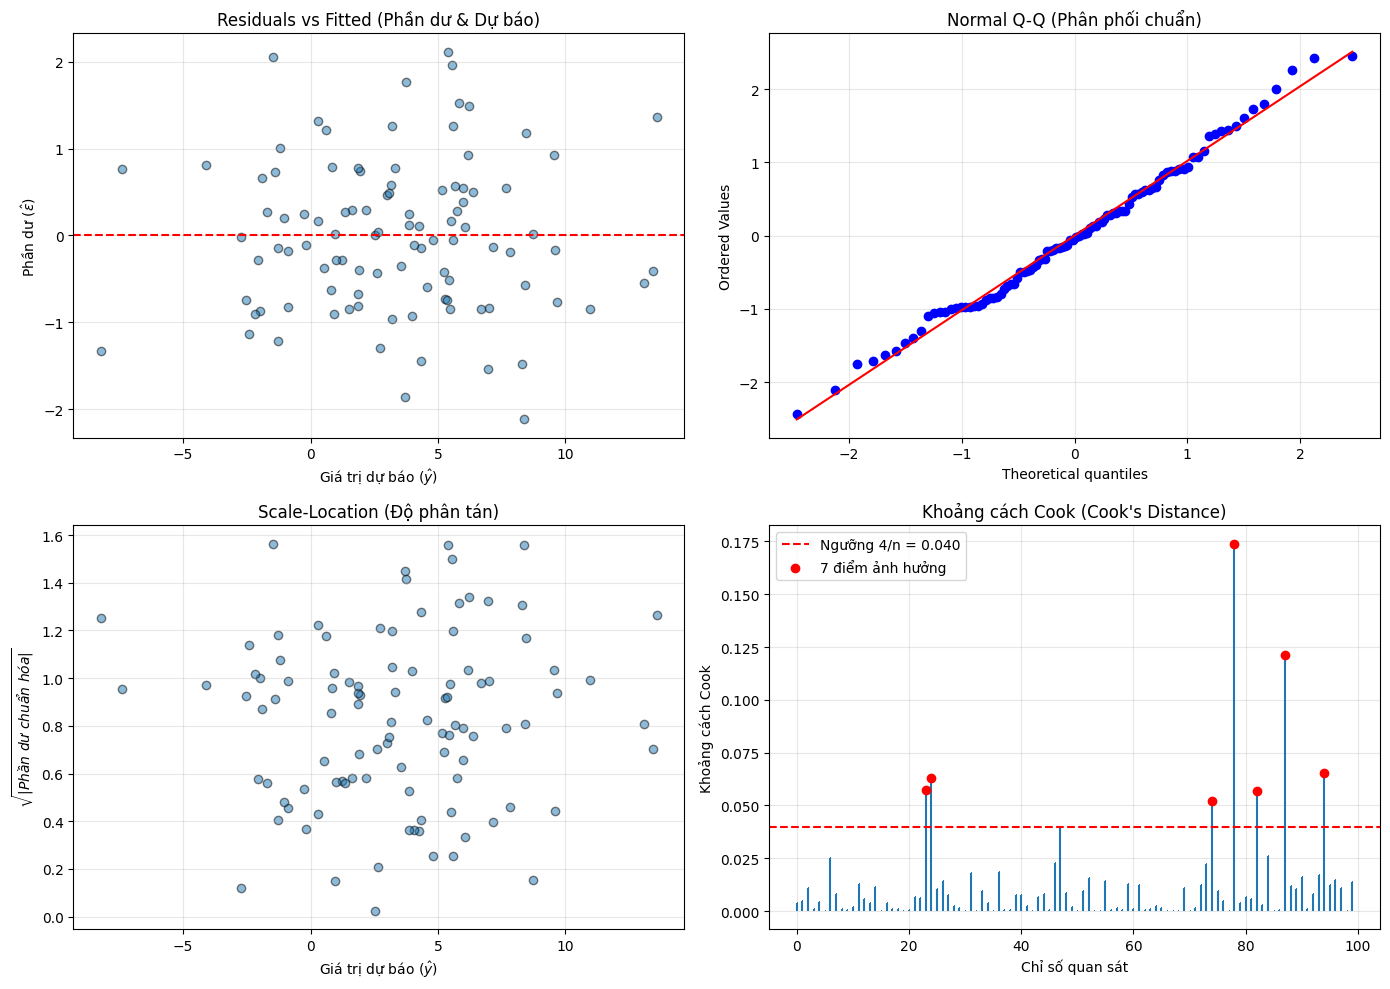

(array([-9.54340568e-01, -6.80285940e-01,  8.62784238e-01,  5.29498839e-01,
        -4.64258106e-01, -6.38509523e-02,  1.36620528e+00, -9.97823188e-01,
         3.13074896e-01, -3.93921681e-01, -3.32324368e-01,  9.42125433e-01,
         5.68699361e-01,  8.77408041e-01,  1.15598138e+00, -6.51063026e-02,
         6.22665777e-01, -4.78423344e-01,  2.84701118e-01, -1.65707383e-01,
        -2.07290829e-01,  6.67572223e-01, -9.67652450e-01,  2.42593084e+00,
        -1.56751795e+00, -1.46835341e+00,  1.07234773e+00,  8.33614993e-01,
         5.95881983e-01,  6.46125778e-01, -1.65241691e-01, -1.39094676e+00,
        -5.28978444e-04, -1.05836600e+00,  8.84735781e-01, -1.34140061e-01,
        -1.29899294e+00, -1.95422020e-01,  3.36196013e-01, -7.28715044e-01,
        -8.81802770e-01,  3.37110934e-01,  4.30004702e-02, -8.36632438e-01,
        -8.54145763e-01,  1.91046062e-01, -1.75385678e+00, -1.71063511e+00,
        -1.03586768e+00, -4.27120262e-01,  1.83625928e-01,  1.49748229e+00,
         9.1

In [6]:
residual_plots(X, y, beta_hat)

### 7. K-Fold Cross Validation

Đánh giá độ ổn định của mô hình trên dữ liệu chưa biết.

In [7]:
cv_score, mse_list = kfold_cv(X, y, k=5)

=== Kết quả 5-Fold CV ===
  Fold 1: MSE = 0.9474
  Fold 2: MSE = 0.8359
  Fold 3: MSE = 0.9831
  Fold 4: MSE = 0.8658
  Fold 5: MSE = 0.5503
  CV Score (Mean MSE) = 0.8365


### 8. Minh họa định lý Gauss-Markov (Monte Carlo Simulation)

Kiểm chứng:
1. $E[\hat{\beta}] = \beta$ (Không chệch)
2. OLS có phương sai nhỏ nhất (BLUE)

Đang chạy 1000 lần mô phỏng...
KẾT QUẢ MÔ PHỎNG MONTE CARLO (KIỂM CHỨNG GAUSS-MARKOV)
Số mẫu: 100, Số đặc trưng: 3
Beta thực tế: [ 2.5  1.5 -2.   3. ]
------------------------------------------------------------
1. KIỂM CHỨNG TÍNH KHÔNG CHỆCH (E[beta_hat] = beta):
   Trung bình Beta OLS: [ 2.5012  1.5025 -2.003   2.9945]
   Trung bình Beta Alt: [ 2.7517  1.5313 -1.8907  3.2206]
   => Nhận xét: Cả hai đều hội tụ về giá trị thực.
------------------------------------------------------------
2. KIỂM CHỨNG PHƯƠNG SAI NHỎ NHẤT (BLUE):
   Phương sai Beta OLS: [0.0256 0.0371 0.0237 0.02  ]
   Phương sai Beta Alt: [144.4803 240.9104 181.2796 248.682 ]
   => Nhận xét: Phương sai của OLS nhỏ hơn đáng kể.


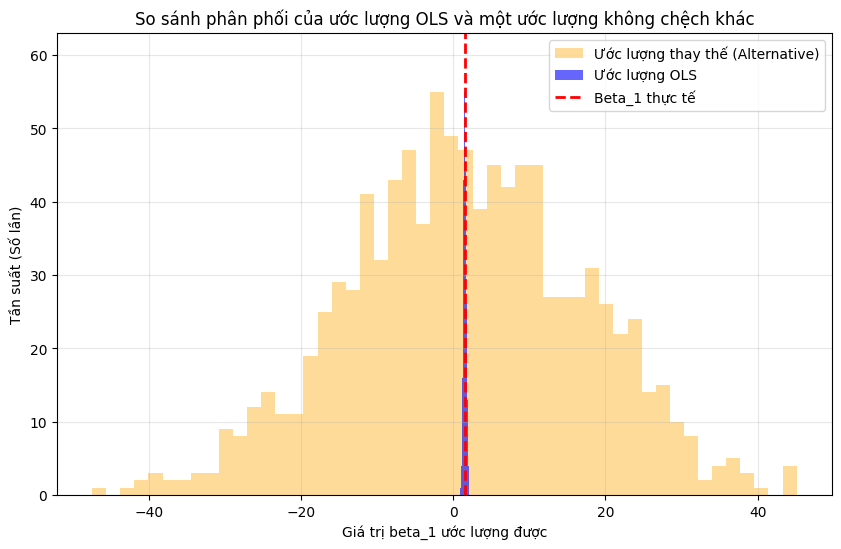

In [8]:
run_monte_carlo(n_simulations=1000)